___

<img src='../ulster_logo.png' /></a>
___
# Linear Regression Project

Congratulations! You just got some contract work with an Ecommerce company based in New York City that sells clothing online but they also have in-store style and clothing advice sessions. Customers come in to the store, have sessions/meetings with a personal stylist, then they can go home and order either on a mobile app or website for the clothes they want.

The company is trying to decide whether to focus their efforts on their mobile app experience or their website. They've hired you on contract to help them figure it out! Let's get started!

Just follow the steps below to analyze the customer data (it's fake, don't worry I didn't give you real credit card numbers or emails).

## Imports
** Import pandas, numpy, matplotlib,and seaborn. Then set %matplotlib inline 
(You'll import sklearn as you need it.)**

In [1]:
# 1st step I will be importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier 
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

## Get the Data

We'll work with the Ecommerce Customers csv file from the company. It has Customer info, suchas Email, Address, and their color Avatar. Then it also has numerical value columns:

* Avg. Session Length: Average session of in-store style advice sessions.
* Time on App: Average time spent on App in minutes
* Time on Website: Average time spent on Website in minutes
* Length of Membership: How many years the customer has been a member. 

** Read in the Ecommerce Customers csv file as a DataFrame called customers.**

In [2]:
df_customers= pd.read_csv('Ecommerce Customers.csv')

**Check the head of customers, and check out its info() and describe() methods.**

In [3]:
df_customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df_customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


## Exploratory Data Analysis

**Let's explore the data!**

For the rest of the exercise we'll only be using the numerical data of the csv file.
___
**Use seaborn to create a jointplot to compare the Time on Website and Yearly Amount Spent columns. Does the correlation make sense?**

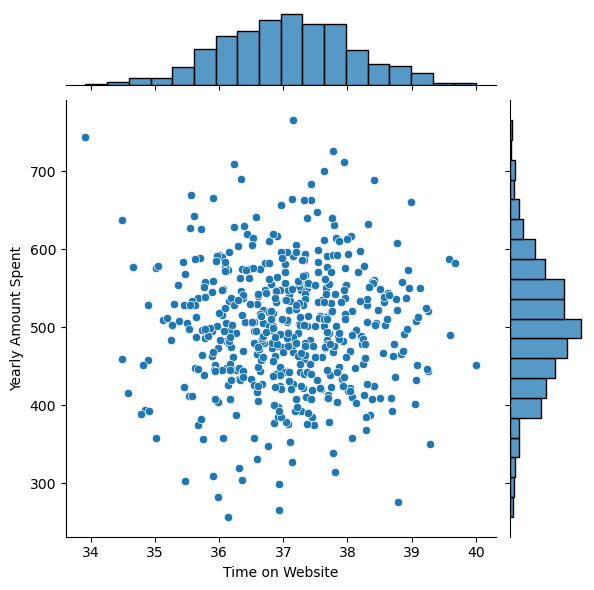

In [6]:
sns.jointplot(x = 'Time on Website',y= 'Yearly Amount Spent', data = df_customers, height=6)
plt.show()
# the below jointplot displays the yearly amount spent vs time on website. if we observe the scatterplot
# the value of "x" increases so as the value of"y

** Do the same but with the Time on App column instead. **

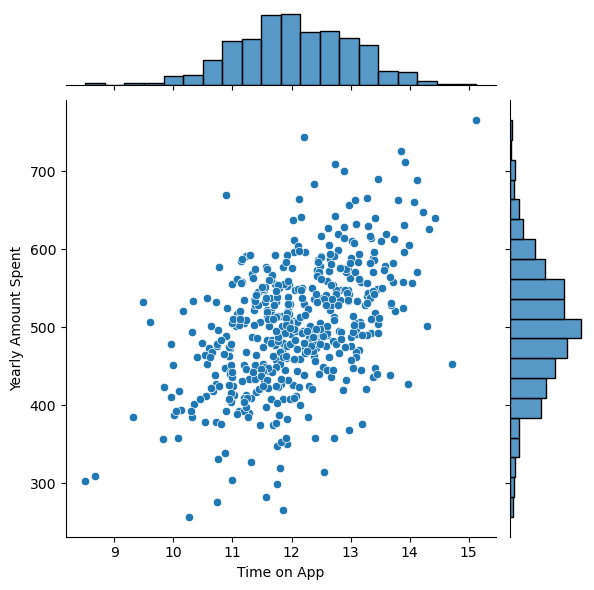

<Figure size 600x600 with 0 Axes>

In [7]:
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=df_customers)
plt.figure(figsize=(6,6))
plt.show()
# the below jointplot displays the time on app vs yearly amount spent.

** Use jointplot to create a 2D hex bin plot comparing Time on App and Length of Membership.**

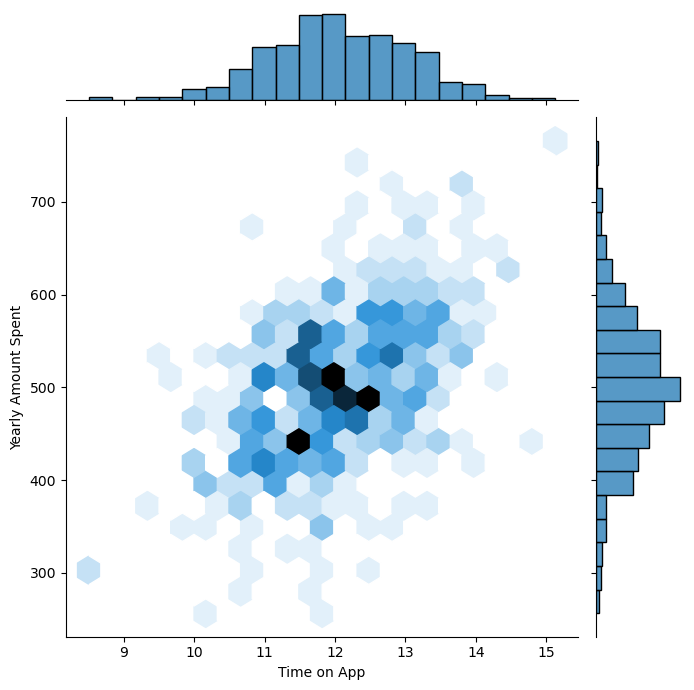

<Figure size 600x600 with 0 Axes>

In [8]:
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=df_customers,kind="hex", height=7, ratio=5)
plt.figure(figsize=(6,6))
plt.show()
# sns.jointplot(x=x, y=y, kind="hex", data= df_customers)
# # x='Time on App'
# # y='Length of Membership'
# # plt.hexbin(x, y)
# # plot.show()

**Let's explore these types of relationships across the entire data set. Use [pairplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/axis_grids.html#plotting-pairwise-relationships-with-pairgrid-and-pairplot) to recreate the plot below.(Don't worry about the the colors)**

C:\Users\adhil\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


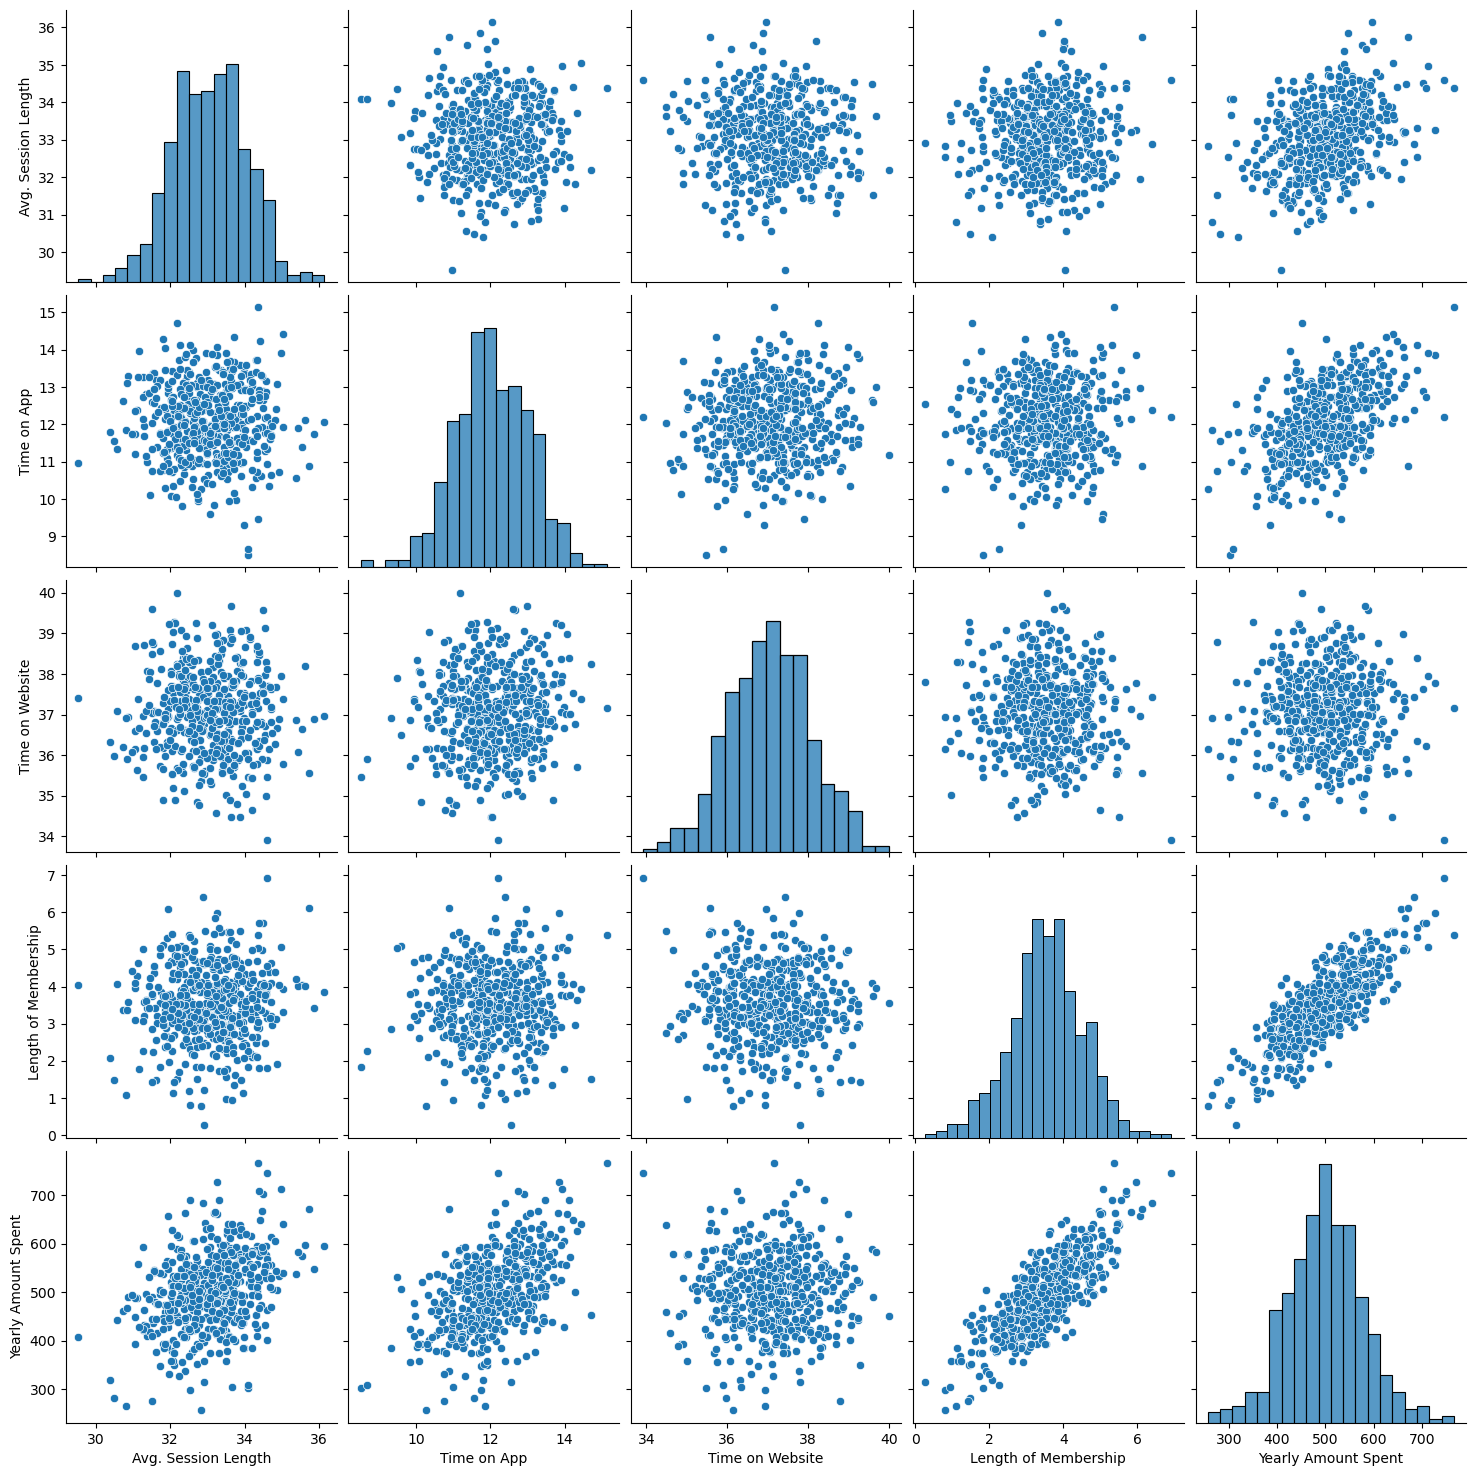

In [9]:
sns.pairplot(data=df_customers, kind='scatter', height=3)
plt.show()

**Based off this plot what looks to be the most correlated feature with Yearly Amount Spent?**

In [10]:
# The length of Membership looks to be the most correlated feature with Yearly Amount Spent

**Create a linear model plot (using seaborn's lmplot) of  Yearly Amount Spent vs. Length of Membership. **

C:\Users\adhil\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


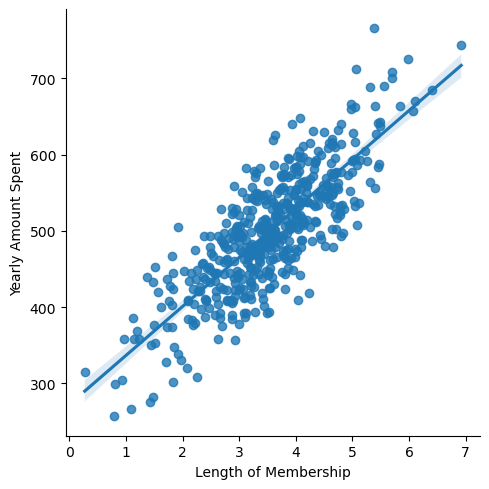

In [11]:
sns.lmplot(x='Length of Membership', y='Yearly Amount Spent', data=df_customers)
plt.show()

## Training and Testing Data

Now that we've explored the data a bit, let's go ahead and split the data into training and testing sets.
** Set a variable X equal to the numerical features of the customers and a variable y equal to the "Yearly Amount Spent" column. **

In [12]:
# Selecting numerical features as X
X = df_customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]

In [13]:
# Selecting the target variable as y
y = df_customers['Yearly Amount Spent']

** Use model_selection.train_test_split from sklearn to split the data into training and testing sets. Set test_size=0.3 and random_state=101**

In [14]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [15]:
#scaling the training data
scaler = StandardScaler()
#scaler on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training the Model

Now its time to train our model on our training data!

** Import LinearRegression from sklearn.linear_model **

In [16]:
#Already imported above in line no 1

**Create an instance of a LinearRegression() model named lm.**

In [17]:
lm = LinearRegression()

** Train/fit lm on the training data.**

In [21]:
lm.fit(X_train, y_train)


LinearRegression()

In [19]:
lm.intercept_

-1047.932782250239

**Print out the coefficients of the model**

In [23]:
# Retrieving the coefficients of the model
coefficients = lm.coef_

# Printing out the coefficients
print("Coefficients:", coefficients)


Coefficients: [25.98154972 38.59015875  0.19040528 61.27909654]


## Predicting Test Data
Now that we have fit our model, let's evaluate its performance by predicting off the test values!

** Use lm.predict() to predict off the X_test set of the data.**

In [38]:
# Predicting the values for the test set
predictions_lm = lm.predict(X_test)


** Create a scatterplot of the real test values versus the predicted values. **

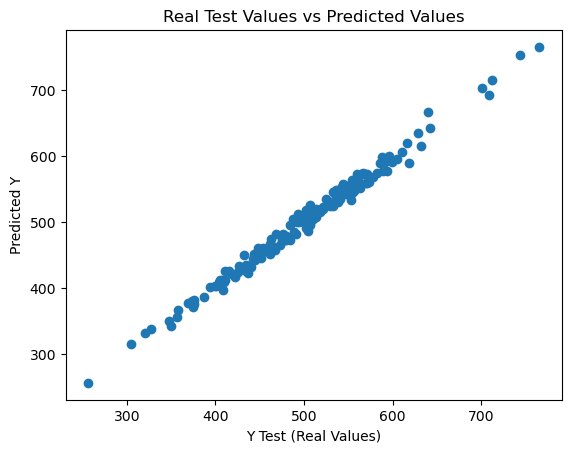

In [39]:
# plt.figure(figsize=(5,5))
plt.scatter(y_test, predictions_lm)
plt.xlabel('Y Test (Real Values)')
plt.ylabel('Predicted Y')
plt.title('Real Test Values vs Predicted Values')
plt.show()


## Evaluating the Model

Let's evaluate our model performance by calculating the residual sum of squares and the explained variance score (R^2).

** Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error. Refer to the lecture or to Wikipedia for the formulas**

In [40]:
# Mean Absolute Error (MAE)
mae = metrics.mean_absolute_error(y_test, predictions_lm)

# Mean Squared Error (MSE)
mse = metrics.mean_squared_error(y_test, predictions_lm)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)


Mean Absolute Error: 7.228148653430832
Mean Squared Error: 79.81305165097444
Root Mean Squared Error: 8.933815066978633


In [ ]:
# The Mean Absolute Error(MAE) is the average of all absolute errors.
# Mean square error is calculated by taking the average, 
# specifically the mean, of errors squared from data as it relates to a function
# the root-mean-square error (RMSE) is a frequently used measure of the differences between values (sample or population values) 
# predicted by a model or an estimator and the values observed.

## Residuals

You should have gotten a very good model with a good fit. Let's quickly explore the residuals to make sure everything was okay with our data. 

**Plot a histogram of the residuals and make sure it looks normally distributed. Use either seaborn distplot, or just plt.hist().**

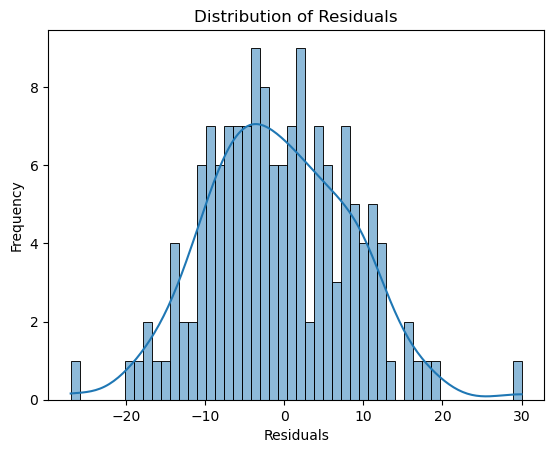

In [41]:
residuals = y_test - predictions_lm

sns.histplot(residuals, kde=True, bins=50)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

## Conclusion
We still want to figure out the answer to the original question, do we focus our efforst on mobile app or website development? Or maybe that doesn't even really matter, and Membership Time is what is really important.  Let's see if we can interpret the coefficients at all to get an idea.

** Recreate the dataframe below. **

In [42]:
# Creating a DataFrame for coefficients
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lm.coef_})
coefficients_df

,Feature,Coefficient
0,Avg. Session Length,25.981550
1,Time on App,38.590159
2,Time on Website,0.190405
3,Length of Membership,61.279097


In [ ]:
#the coefficients in the above dataframe describes the influence of the variables
# ex. for avgsession length the coefficient is 25.98 which means there is one unit 
# increase in yearly amount spent. taking the time on app into consideration for every one 
# unit increase in yearly amount spent is 38.59. the time on website is lowest when take into consideration regarding the yearly amount spent.

**Do you think the company should focus more on their mobile app or on their website?**

In [66]:
#the company should focus more on their mobile app but the company should not also abandon their website but they should try to fix and build a good website. 
# As access to mobile app is much easier than website through mobile phones. 

## Great Job!

Congrats on your contract work! The company loved the insights! Let's move on.

# Decision tree regressor

In [106]:
# for the 1st step the libraries have already been imported,
#The has also been and the data has also been loaded

# Spliting the dataset in feature and target variables

In [50]:
feature_cs=['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']
x=df_customers[feature_cs]
y=df_customers['Yearly Amount Spent']

## Spliting the data into training and test set

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## Building decision tree regressor model 

In [52]:
# creating a decision tree regressor
regressor= DecisionTreeRegressor()

In [53]:
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [54]:
predictions_dtr = regressor.predict(X_test)

In [55]:
mse = metrics.mean_squared_error(y_test, predictions_dtr)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 873.9048487206153


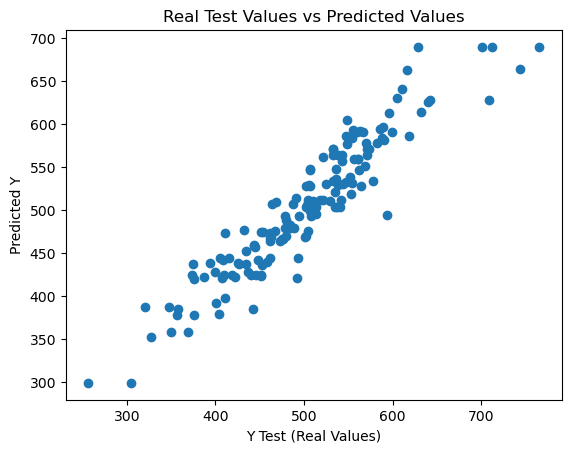

In [56]:
plt.scatter(y_test, predictions_dtr)
plt.xlabel('Y Test (Real Values)')
plt.ylabel('Predicted Y')
plt.title('Real Test Values vs Predicted Values')
plt.show()

# Evaluting the model

In [57]:
# Mean Absolute Error (MAE)
mae = metrics.mean_absolute_error(y_test, predictions_dtr)

# Mean Squared Error (MSE)
mse = metrics.mean_squared_error(y_test, predictions_dtr)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)


Mean Absolute Error: 22.806298029468
Mean Squared Error: 873.9048487206153
Root Mean Squared Error: 29.56188168436873


## Support Vector Regression

# Define features and target variable

In [58]:
X = df_customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df_customers['Yearly Amount Spent'] 

# Split the data into training and testing sets

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Scale the features

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Support Vector Regression model

In [61]:
model = SVR(kernel='linear')
model.fit(X_train_scaled, y_train)

SVR(kernel='linear')

# Predict on the test set

In [62]:
predictions_sv = model.predict(X_test_scaled)

# Evaluate the model

In [63]:
print(f"Model R^2 score: {model.score(X_test_scaled, y_test)}")

Model R^2 score: 0.988376601010969



# Visualize predicted vs actual values


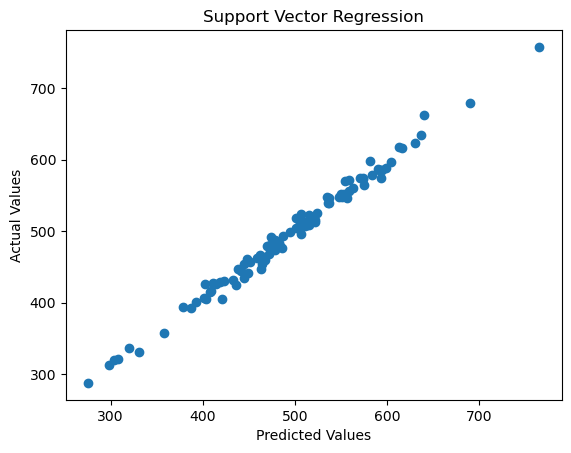

Model R^2 score: 0.988376601010969


In [64]:
plt.scatter(y_test, predictions_sv)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Support Vector Regression')
plt.show()
print(f"Model R^2 score: {model.score(X_test_scaled, y_test)}")

In [65]:
# Mean Absolute Error (MAE)
mae = metrics.mean_absolute_error(y_test, predictions_sv)

# Mean Squared Error (MSE)
mse = metrics.mean_squared_error(y_test, predictions_sv)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)

Mean Absolute Error: 7.400110344794225
Mean Squared Error: 84.9637216614764
Root Mean Squared Error: 9.217576778170953


# CONSLUSION

In [ ]:
# the linear regression model had the lowest mean absolute error this,
# explains that it was one of the best fitted model from the other two models. 
# in my opinion the linear regression model was the best due to the data
# and the relationship between features and target variable.
# further experiments can also be done if we change the features and the target variable. 